# Notebook 12 — Stratified 10-fold Cross-Validation (Philippine)

**What this notebook does.** Loads the per-fold metrics produced by `scripts/stratified_cv.py` and shows which algorithm wins under the standard ML benchmark protocol (shuffle + stratify, ignore time).

**Why a second CV scheme?** The headline thesis pipeline uses *chronological* splits — train on older bookings, test on newer ones — because that's how the model will be used in production. Stratified 10-fold CV is the *algorithm-comparison* number you'd see in a published ML paper: every row gets to be in the test set exactly once, and each fold preserves the positive-class ratio. Both numbers belong in the thesis; they answer different questions.

**Reading this page.** Each chart compares the same seven algorithms on the same ten folds. "Best" means "highest mean PR-AUC across folds" because PR-AUC is the project's primary metric (the dataset is imbalanced — see `positive_rate` below).

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

from src.eval.notebook_utils import save_thesis_figure, setup_plotting

cfg = setup_plotting()
FIG_DIR = cfg["fig_dir"]
ROOT = Path.cwd()
while not (ROOT / "reports").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

DATASET = "philippine"
FIG_NO_BASE = 200
CV_DIR = ROOT / "reports" / "cv"
FOLD_PATH = CV_DIR / f"{DATASET}_stratified_10fold_folds.csv"
SUMMARY_PATH = CV_DIR / f"{DATASET}_stratified_10fold_summary.json"

fold_df = pd.read_csv(FOLD_PATH)
summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8"))
meta = summary["dataset_meta"]

print(f"Dataset       : {DATASET}")
print(f"Rows used     : {meta['n_rows_used']:,}")
print(f"Positive rate : {meta['positive_rate']:.4f}")
print(f"Folds         : {meta['n_splits']} (stratified, shuffle=True, seed={meta['random_state']})")
print(f"Algorithms    : {len(summary['per_algorithm'])}")
skipped = summary.get("skipped_algorithms", [])
if skipped:
    print("Skipped       :", ", ".join(f"{s['algorithm']} ({s['reason']})" for s in skipped))


Dataset       : philippine
Rows used     : 193
Positive rate : 0.1503
Folds         : 10 (stratified, shuffle=True, seed=42)
Algorithms    : 7


## How wide is the spread across folds?

Box plots show the per-fold distribution of PR-AUC and ROC-AUC for each algorithm. A tall box means "this algorithm is unstable"; a tight box means "you get the same answer every time you re-shuffle the data".

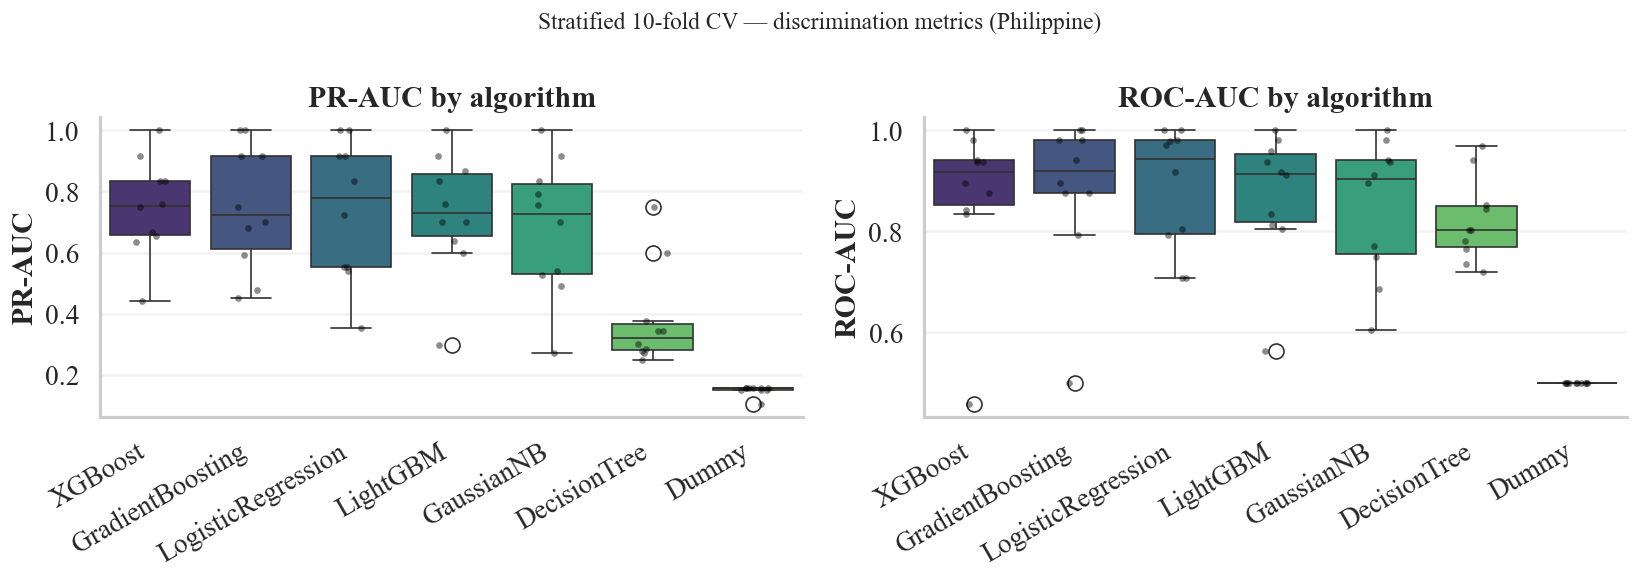

In [2]:
# Order algorithms by mean PR-AUC (descending) so the visual reads "best on the left".
order = [r["algorithm"] for r in summary["ranking"]]
plot_df = fold_df[fold_df["algorithm"].isin(order)].copy()
plot_df["algorithm"] = pd.Categorical(plot_df["algorithm"], categories=order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, metric, title in zip(axes, ["pr_auc", "roc_auc"], ["PR-AUC by algorithm", "ROC-AUC by algorithm"]):
    sns.boxplot(data=plot_df, x="algorithm", y=metric, ax=ax,
                palette="viridis", showfliers=True)
    sns.stripplot(data=plot_df, x="algorithm", y=metric, ax=ax,
                  color="black", alpha=0.45, size=4, jitter=0.15)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(metric.replace('_', '-').upper())
    ax.tick_params(axis="x", rotation=30)
    for tick in ax.get_xticklabels():
        tick.set_horizontalalignment("right")
fig.suptitle(f"Stratified 10-fold CV — discrimination metrics ({DATASET.title()})", fontsize=14)
fig.tight_layout()
save_thesis_figure(fig, f"{FIG_NO_BASE}", f"stratified_kfold_box_{DATASET}", FIG_DIR)
plt.show()


### Key Takeaway (plain English)

Look at the leftmost boxes. The algorithm with the highest *and tightest* box is the safest choice — high mean, low variance across folds. If the top algorithms have overlapping boxes, that means the data does not strongly discriminate between them, and the win could flip with a different random seed.

## The leaderboard

The table below ranks every algorithm by mean PR-AUC across the ten folds. **PR-AUC 95% CI** is the normal-approximation interval on the mean — when two algorithms' intervals overlap, the difference is not statistically meaningful at this fold count. **Fit s (avg)** is the wall-clock training time per fold — a proxy for deployment cost.

In [3]:
rank_rows = []
for entry in summary["per_algorithm"]:
    rank_rows.append(
        {
            "Algorithm": entry["algorithm"],
            "PR-AUC mean": entry["pr_auc"]["mean"],
            "PR-AUC std":  entry["pr_auc"]["std"],
            "PR-AUC 95% CI": f"[{entry['pr_auc']['ci95_low']:.3f}, {entry['pr_auc']['ci95_high']:.3f}]",
            "ROC-AUC mean": entry["roc_auc"]["mean"],
            "ROC-AUC std":  entry["roc_auc"]["std"],
            "Brier mean":   entry["brier"]["mean"],
            "ECE mean":     entry["ece"]["mean"],
            "F1@0.5 mean":  entry["f1_at_05"]["mean"],
            "Fit s (avg)":  entry["fit_seconds_mean"],
        }
    )
rank_df = pd.DataFrame(rank_rows)
rank_df = rank_df.sort_values("PR-AUC mean", ascending=False).reset_index(drop=True)
rank_df.index = rank_df.index + 1
rank_df.index.name = "Rank"
styled = (
    rank_df.style
    .format(
        {
            "PR-AUC mean": "{:.4f}", "PR-AUC std": "{:.4f}",
            "ROC-AUC mean": "{:.4f}", "ROC-AUC std": "{:.4f}",
            "Brier mean": "{:.4f}", "ECE mean": "{:.4f}",
            "F1@0.5 mean": "{:.4f}", "Fit s (avg)": "{:.2f}",
        }
    )
    .set_caption(f"Stratified 10-fold CV ranking — {DATASET.title()} (ordered by mean PR-AUC)")
)
styled


,Algorithm,PR-AUC mean,PR-AUC std,PR-AUC 95% CI,ROC-AUC mean,ROC-AUC std,Brier mean,ECE mean,F1@0.5 mean,Fit s (avg)
Rank,,,,,,,,,,
1,XGBoost,0.7487,0.1597,"[0.650, 0.848]",0.8702,0.1547,0.0920,0.1188,0.5750,0.05
2,GradientBoosting,0.7484,0.2044,"[0.622, 0.875]",0.8839,0.1509,0.0829,0.1030,0.5371,0.38
3,LogisticRegression,0.7389,0.2274,"[0.598, 0.880]",0.8859,0.1204,0.0820,0.1269,0.5152,1.10
4,LightGBM,0.7312,0.1973,"[0.609, 0.854]",0.8717,0.1286,0.0859,0.1127,0.5357,0.08
5,GaussianNB,0.6828,0.2223,"[0.545, 0.821]",0.8478,0.1353,0.1668,0.2005,0.4887,0.00
6,DecisionTree,0.3798,0.1640,"[0.278, 0.482]",0.8211,0.0824,0.1871,0.2388,0.5109,0.00
7,Dummy,0.1503,0.0162,"[0.140, 0.160]",0.5000,0.0000,0.1503,0.1503,0.0000,0.00


## How often does each algorithm finish first?

A complement to the leaderboard: in how many of the ten folds did this algorithm have the highest PR-AUC? An algorithm with a high mean but few wins is winning by big margins on a few folds and losing the rest — usually a sign of variance, not skill. An algorithm with many wins is consistently the best, even if the average margin is small.

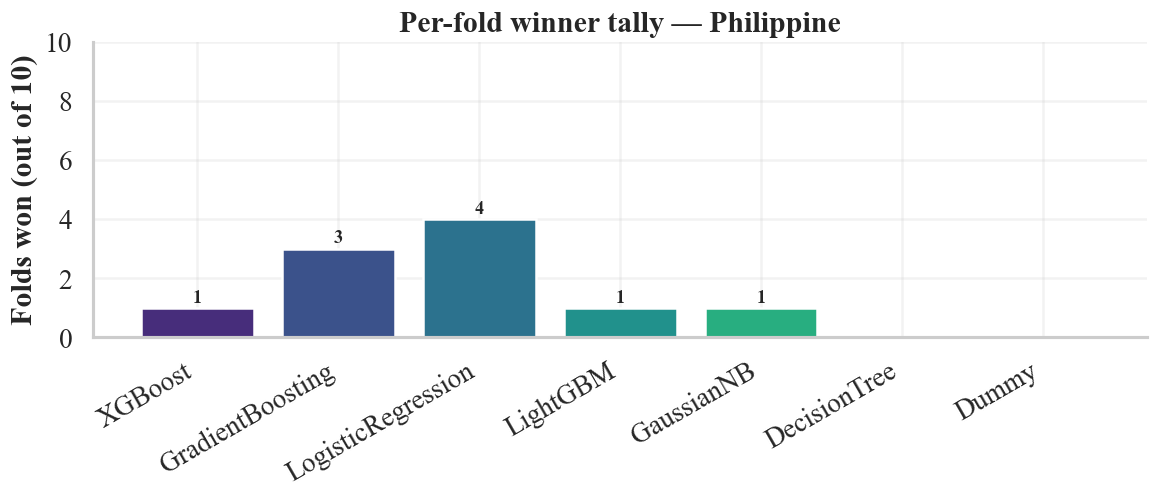


Winners per fold:
 fold          algorithm   pr_auc
    1   GradientBoosting 0.916667
    2 LogisticRegression 1.000000
    3 LogisticRegression 0.916667
    4 LogisticRegression 0.833333
    5 LogisticRegression 1.000000
    6   GradientBoosting 1.000000
    7         GaussianNB 0.791667
    8   GradientBoosting 0.452632
    9           LightGBM 0.700000
   10            XGBoost 0.633333


In [4]:
# Per-fold winner = algorithm with highest PR-AUC for that fold.
winners = (
    fold_df.loc[fold_df.groupby("fold")["pr_auc"].idxmax(), ["fold", "algorithm", "pr_auc"]]
    .reset_index(drop=True)
)
win_counts = winners["algorithm"].value_counts().reindex(order, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(win_counts.index, win_counts.values, color=sns.color_palette("viridis", n_colors=len(win_counts)))
ax.set_ylabel("Folds won (out of {})".format(int(meta["n_splits"])))
ax.set_title(f"Per-fold winner tally — {DATASET.title()}")
ax.tick_params(axis="x", rotation=30)
for tick in ax.get_xticklabels():
    tick.set_horizontalalignment("right")
for bar, value in zip(bars, win_counts.values):
    if value > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, str(int(value)),
                ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(0, max(int(win_counts.max()) + 1, int(meta["n_splits"])))
sns.despine()
fig.tight_layout()
save_thesis_figure(fig, f"{FIG_NO_BASE + 1}", f"stratified_kfold_winners_{DATASET}", FIG_DIR)
plt.show()
print("\nWinners per fold:")
print(winners.to_string(index=False))


## Calibration quality (raw probabilities)

Brier score and Expected Calibration Error (ECE) measure how *honest* the predicted probabilities are. **These numbers do NOT include the isotonic calibration step** from the deployment pipeline — they show the algorithm's out-of-the-box calibration. Tree-based models often score worse here than logistic regression because they push probabilities toward 0 or 1; that's exactly why the deployment pipeline applies isotonic regression on top.

In [5]:
# Brier + ECE comparison — calibration quality on RAW probabilities (no per-fold isotonic).
cal_df = (
    fold_df.groupby("algorithm")[["brier", "ece"]]
    .agg(["mean", "std"])
    .reindex(order)
    .round(4)
)
cal_df.columns = ["_".join(c).rstrip("_") for c in cal_df.columns]
cal_df


,brier_mean,brier_std,ece_mean,ece_std
algorithm,,,,
XGBoost,0.0920,0.0439,0.1188,0.0455
GradientBoosting,0.0829,0.0435,0.1030,0.0455
LogisticRegression,0.0820,0.0411,0.1269,0.0463
LightGBM,0.0859,0.0364,0.1127,0.0359
GaussianNB,0.1668,0.0949,0.2005,0.1057
DecisionTree,0.1871,0.0681,0.2388,0.0895
Dummy,0.1503,0.0162,0.1503,0.0162


## Side-by-side: stratified k-fold vs the chronological pipeline

Numbers from this notebook are **not** directly comparable to `reports/metrics.json` — that file reports the chronological-split test metrics. Differences between the two reflect concept drift over time (seasonality, changing booking behaviour). The k-fold number is usually higher because shuffling defeats the chronological generalisation challenge.

In [6]:
chrono_path = ROOT / "reports" / "ph" / "ph_transferability.json"
chrono_label = "Chronological 80/10/10 split (canonical PH pipeline)"
if chrono_path.exists():
    chrono = json.loads(chrono_path.read_text(encoding="utf-8"))
    block = chrono.get('max_f1') or chrono.get('max_f1_test') or {}
    print(f"{chrono_label}:")
    for k in ("roc_auc", "pr_auc", "precision", "recall", "f1"):
        if k in block:
            print(f"  {k:9s} = {block[k]:.4f}")
else:
    print(f"Chronological reference file not found at {chrono_path} — skipping side-by-side.")

champion_row = next(
    (e for e in summary["per_algorithm"] if e["algorithm"] in ("LightGBM", "GradientBoosting", "XGBoost")),
    None,
)
if champion_row is not None:
    print(f"\nStratified 10-fold ({champion_row['algorithm']}):")
    for k in ("pr_auc", "roc_auc"):
        print(f"  {k:9s} = {champion_row[k]['mean']:.4f} ± {champion_row[k]['std']:.4f}")


Chronological 80/10/10 split (canonical PH pipeline):
  roc_auc   = 0.6111
  pr_auc    = 0.5419
  precision = 0.0000
  recall    = 0.0000
  f1        = 0.0000

Stratified 10-fold (GradientBoosting):
  pr_auc    = 0.7484 ± 0.2044
  roc_auc   = 0.8839 ± 0.1509


### Final Key Takeaway

Stratified 10-fold tells us *which algorithm has the strongest signal when the data is shuffled*. Chronological splits tell us *which algorithm generalises best across time*. The thesis champion is selected by the chronological number because that's what production sees, but the k-fold leaderboard is the standard sanity check that the choice is not an artefact of one particular chronological boundary.